# Colocalisation analysis single timepoint
Detects peaks in a single timepoint scan and calculates distance to closest peak in opposite channel.

In [1]:
# Importing libraries
from kymotools.detect import Detector
from kymotools.kymo import PeakMeasures

import kymotools.io as kio
import numpy as np
import os

/Users/sc13967/Documents/Programming/Python/dna-tethering-by-cohesin/.pixi/envs/default/lib/python3.12/site-packages/kymotools/io.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Parameters
input_path = "./examples/input/" # Path to folder containing images to process
output_path = "./examples/output/" # Path to folder in which to save ouput
channel_1 = 0 # First channel
channel_2 = 1 # Second channel

In [3]:
def get_image(path, channel):
    image = kio.read_image(path,channel,x_range=None)
    image = np.moveaxis(image,1,0)
    image = np.average(image,axis=1)
    
    return image[...,np.newaxis]
    
def process(input_path, output_path, name):
    # Loading images
    image_1 = get_image(input_path+name, channel_1)
    image_2 = get_image(input_path+name, channel_2)

    # Initialising Detector
    detector = Detector(half_t_w=0,peak_det_thresh = 1.2, n_max=20, a_lb = 0.5, c_lb=2, c_ub=6, c_def=4)

    # Detecting
    peaks_1 = detector.fit_peaks(image_1[:,0])[0]
    peaks_2 = detector.fit_peaks(image_2[:,0])[0]

    # Nearest neighbour measurement
    for peak_1 in peaks_1.values():
        peak_1.calculate_nearest_neighbour(peaks_2)

    for peak_2 in peaks_2.values():
        peak_2.calculate_nearest_neighbour(peaks_1)

    # Visualisation
    kio.plot_gauss_for_frame(peaks_1,0,image_1,half_t_w=0)
    kio.plot_gauss_for_frame(peaks_2,0,image_2,half_t_w=0)

    # Saving CSV
    rootname = os.path.splitext(name)[0]
    kio.write_peak_data(peaks_1, output_path+rootname+"_peaks1.csv", extra_columns=[PeakMeasures.NN_DIST,PeakMeasures.NN_ID])
    kio.write_peak_data(peaks_2, output_path+rootname+"_peaks2.csv", extra_columns=[PeakMeasures.NN_DIST,PeakMeasures.NN_ID])
    

Processing:  20230324-145634 Scan 32_32_5 px crop.tif


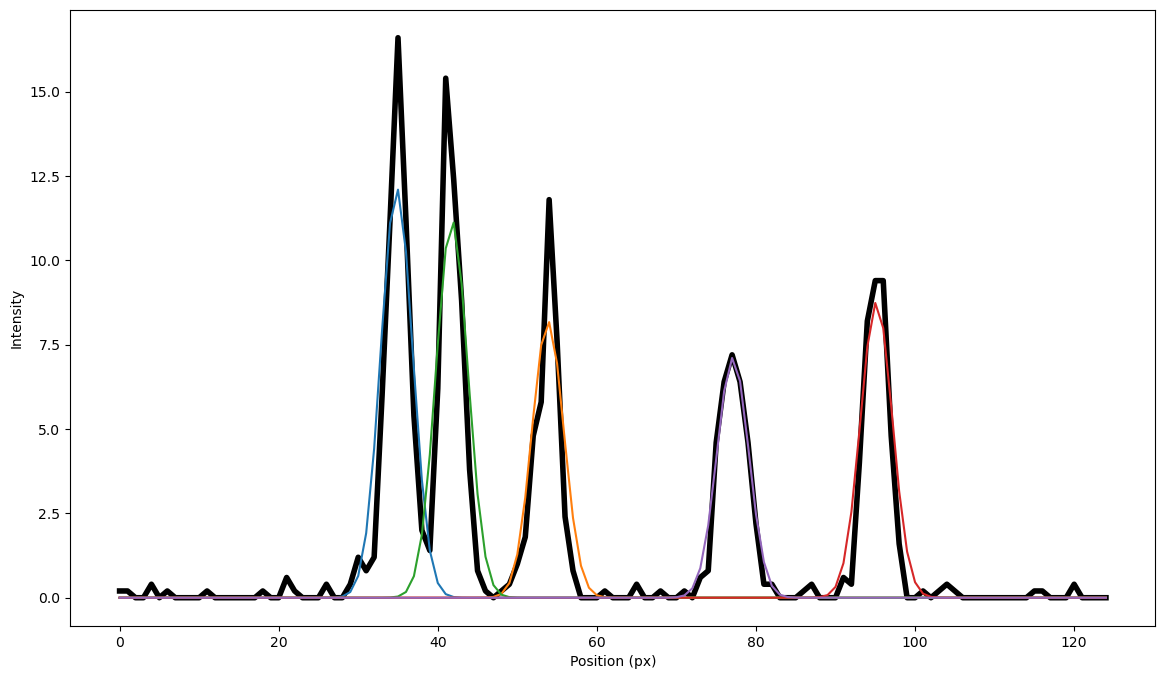

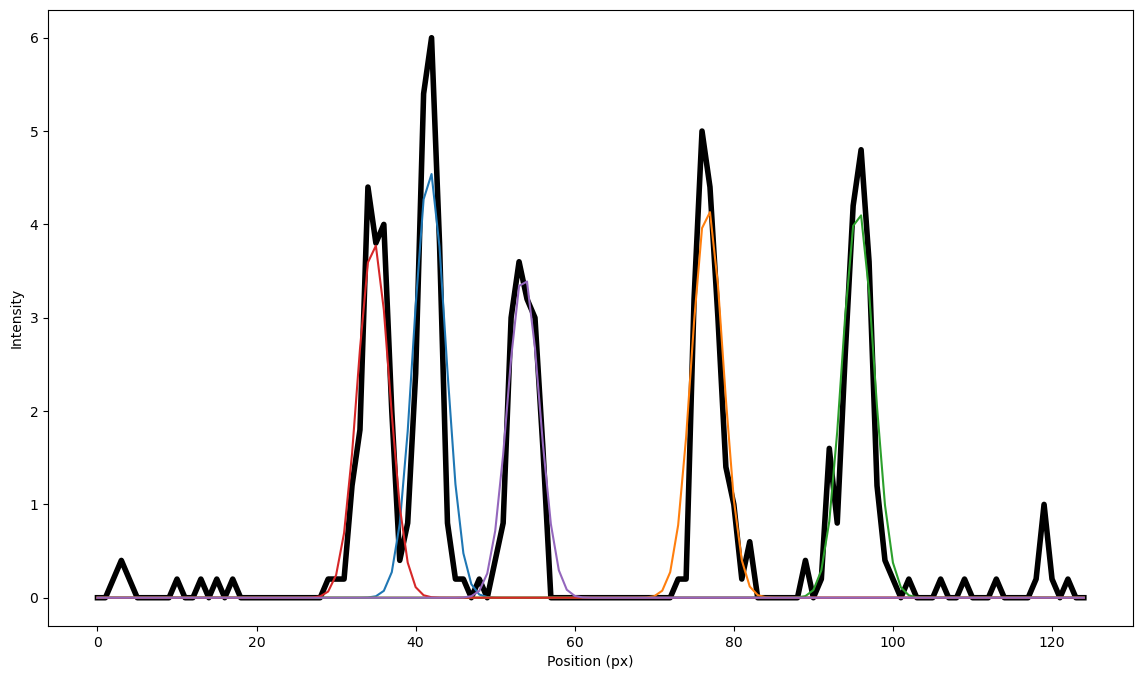

In [4]:
# Looping over all files in folder, processing any tifs
for name in os.listdir(input_path):
    print("Processing: ",name)
    if os.path.splitext(name)[1] == ".tif":
        process(input_path, output_path, name)
